In [37]:
from model_ranking import (
    load_h5,
    get_roi_slice
)
import matplotlib.pyplot as plt
import numpy as np

In [38]:
H_gt_path = "/scratch/talks/data/Hmito/test_converted.h5"
gt_key = "labels"
raw_key = "raw"

# VtoH_def_V_model_Res1

In [17]:
unp_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/VNC_to_Hmito_gap/consistency/finetuned/VtoH_def_V_model_Res1/norm_Normalize/none/predictions/test_converted_predictions.h5"
p_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/VNC_to_Hmito_gap/consistency/finetuned/VtoH_def_V_model_Res1/norm_Normalize/gauss_a01-012/predictions/test_converted_predictions.h5"
patch_indxs = load_h5(p_path, 'patch_index')

In [10]:
EI_consis = load_h5(p_path, "EI_consis")
F1_scores = load_h5(unp_path, "F1_eval")

In [7]:
nan_ids = np.where(np.isnan(EI_consis))[0]
print(len(nan_ids))

19


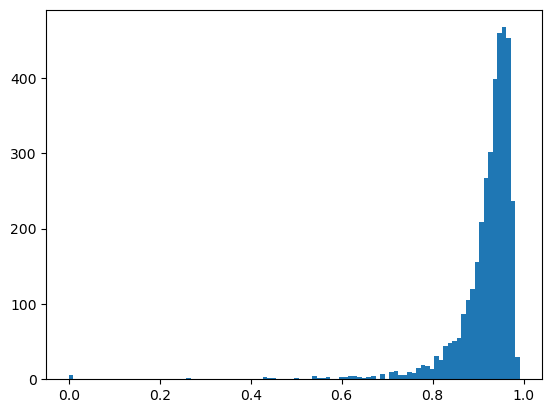

In [5]:
plt.hist(EI_consis, bins=100)
plt.show()

In [15]:
nan_f1s = np.where(np.isnan(F1_scores[:, 1]))[0]
print(len(nan_f1s))

0


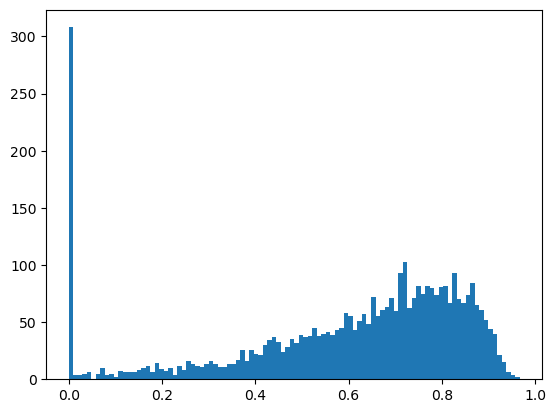

In [14]:
plt.hist(F1_scores[:, 1], bins=100)
plt.show()

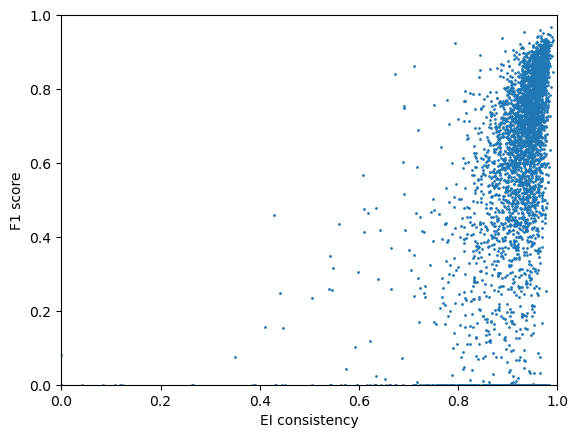

In [12]:
plt.scatter(EI_consis, F1_scores[:, 1], s=1)
plt.xlabel("EI consistency")
plt.ylabel("F1 score")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.show()

In [16]:
f1_zero_ids = np.where(F1_scores[:, 1] == 0)[0]
print(len(f1_zero_ids))

301


In [24]:
f1_ids_not_zero = np.where(F1_scores[:, 1] != 0)[0]
print(len(f1_ids_not_zero))

3449


In [27]:
np.nanmedian(EI_consis)

0.93700284

In [25]:
np.median(EI_consis[f1_ids_not_zero])

0.93896157

In [19]:
patch_indxs[0]

array([[  0,   1],
       [  0, 256],
       [  0, 256]])

In [ ]:
offset = 20
for i in f1_zero_ids[offset:offset+20]:
    _, axs = plt.subplots(1, 4, figsize=(16, 4))
    raw = load_h5(H_gt_path, raw_key, roi=patch_indxs[i])
    gt = load_h5(H_gt_path, gt_key, roi=patch_indxs[i])
    axs[0].imshow(raw.squeeze(), cmap="gray")
    axs[0].set_title("Raw")
    axs[1].imshow(gt.squeeze(), cmap="gray")
    axs[1].set_title("GT")
    p_pred = load_h5(p_path, "predictions", select_index=[i])
    axs[2].imshow(p_pred.squeeze(), cmap="gray")
    axs[2].set_title(f"Perturbed Pred \n EI: {EI_consis[i]:.3f}")
    unp_pred = load_h5(unp_path, "predictions", select_index=[i])
    axs[3].imshow(unp_pred.squeeze(), cmap="gray")
    axs[3].set_title(f"Unperturbed Pred \n F1: {F1_scores[i, 1]:.3f}")
    plt.show()

# RtoH_def_Rm_model_NA2

In [30]:
RtoH_p_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Rmito_to_Hmito_gap/consistency/finetuned/RtoH_def_Rm_model_NA2/norm_Normalize/gauss_a01-012/predictions/test_converted_predictions.h5"
RtoH_unp_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Rmito_to_Hmito_gap/consistency/finetuned/RtoH_def_Rm_model_NA2/norm_Normalize/none/predictions/test_converted_predictions.h5"
R_EI_consis = load_h5(RtoH_p_path, "EI_consis")
R_F1_scores = load_h5(RtoH_unp_path, "F1_eval")

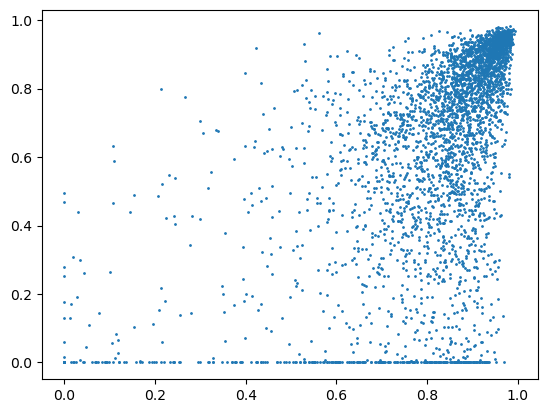

In [31]:
plt.scatter(R_EI_consis, R_F1_scores[:, 1], s=1)
plt.show()

# VtoH_def_V_model2

In [39]:
unp_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/VNC_to_Hmito_gap/consistency/finetuned/VtoH_def_V_model2/norm_Normalize/none/predictions/test_converted_predictions.h5"
p_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/VNC_to_Hmito_gap/consistency/finetuned/VtoH_def_V_model2/norm_Normalize/gauss_a01-012/predictions/test_converted_predictions.h5"
patch_indxs = load_h5(p_path, 'patch_index')

In [40]:
EI_consis = load_h5(p_path, "EI_consis")
F1_scores = load_h5(unp_path, "F1_eval")

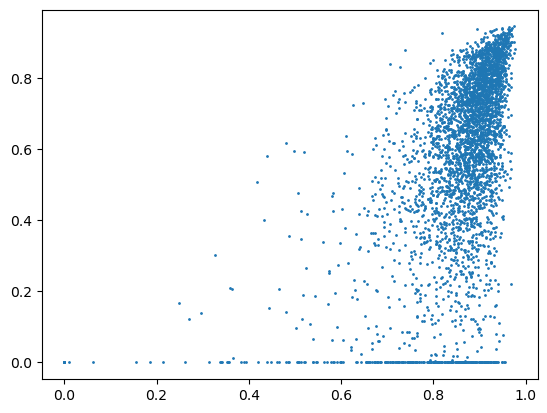

In [41]:
plt.scatter(EI_consis, F1_scores[:, 1], s=1)
plt.show()

In [42]:
zero_f1_ids = np.where(F1_scores[:, 1] == 0)[0]
print(len(zero_f1_ids))

263


In [43]:
f1_ids_not_zero = np.where(F1_scores[:, 1] != 0)[0]
print(len(f1_ids_not_zero))

3487


In [45]:
np.nanmedian(EI_consis)

0.88566864

In [46]:
np.nanmedian(EI_consis[f1_ids_not_zero])

0.8888888

In [47]:
low_f1_high_consis_ids = np.where((F1_scores[:, 1] < 0.2) & (F1_scores[:, 1] > 0) & (EI_consis > 0.8))[0]
print(len(low_f1_high_consis_ids))

79


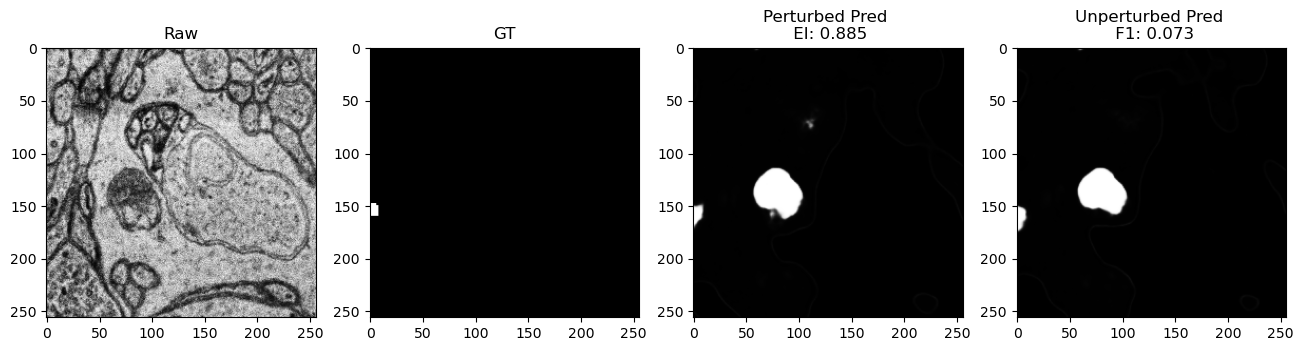

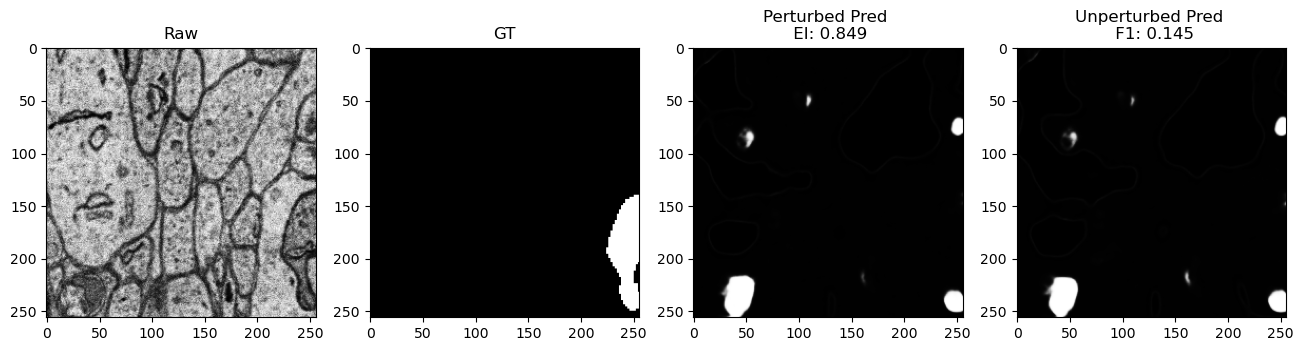

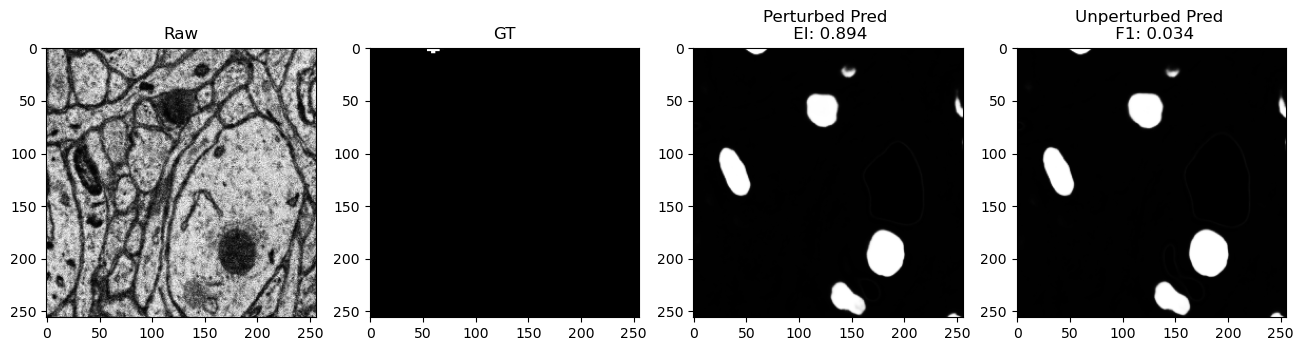

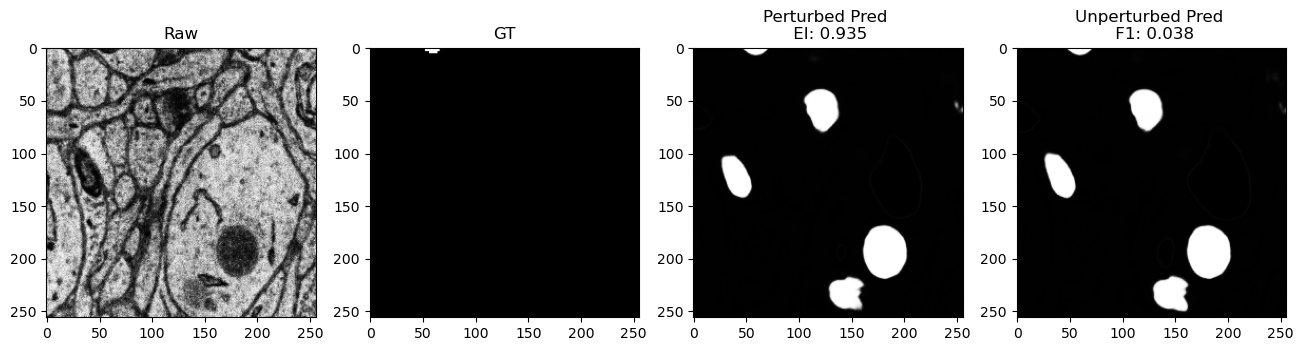

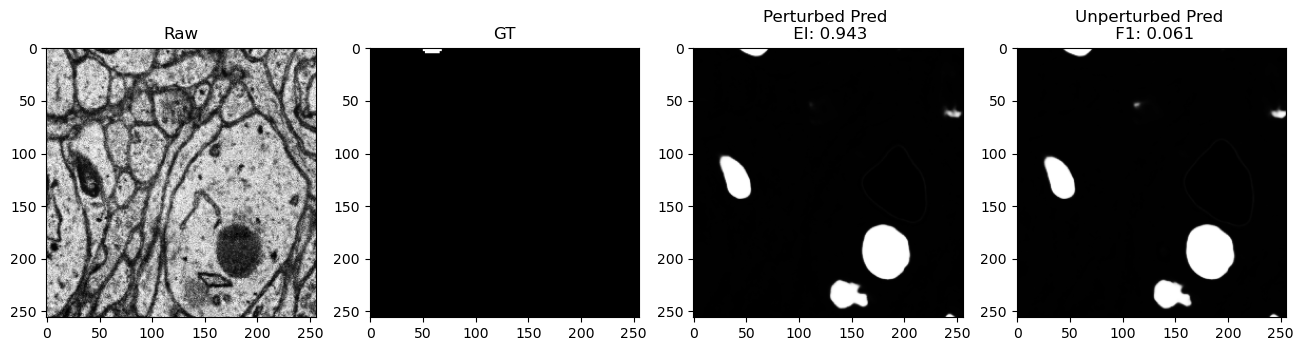

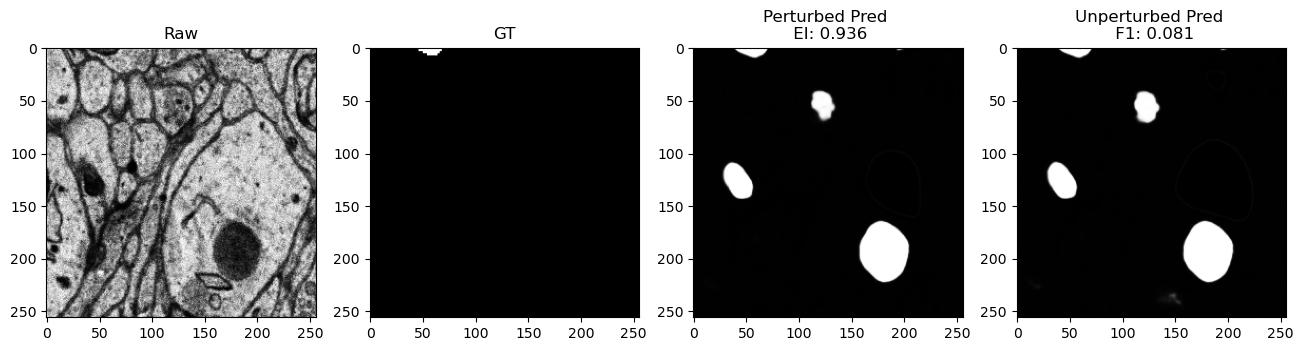

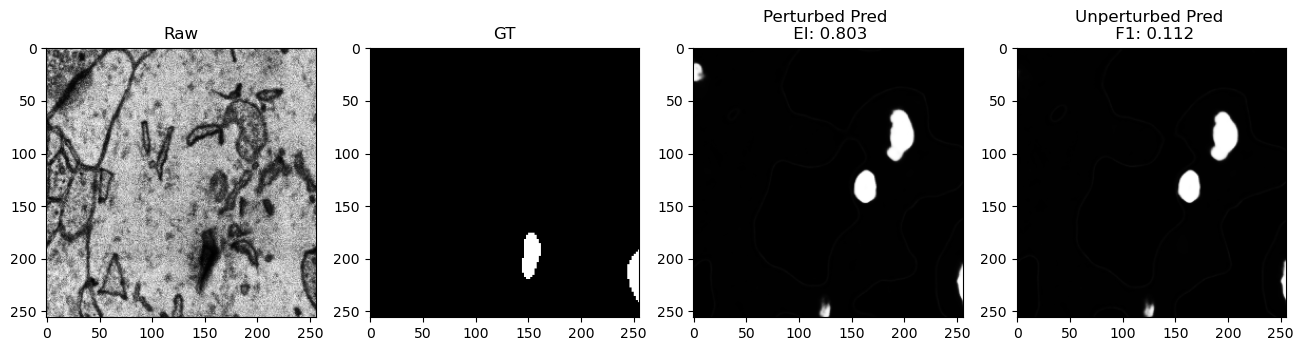

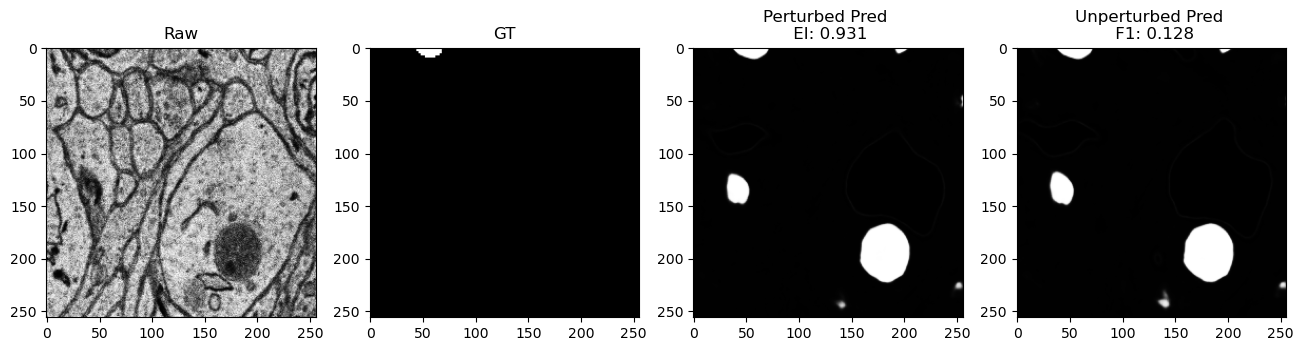

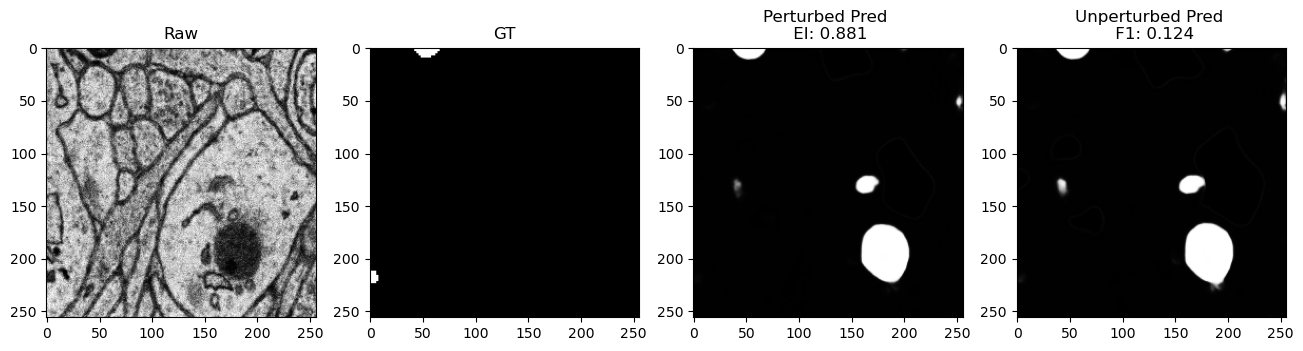

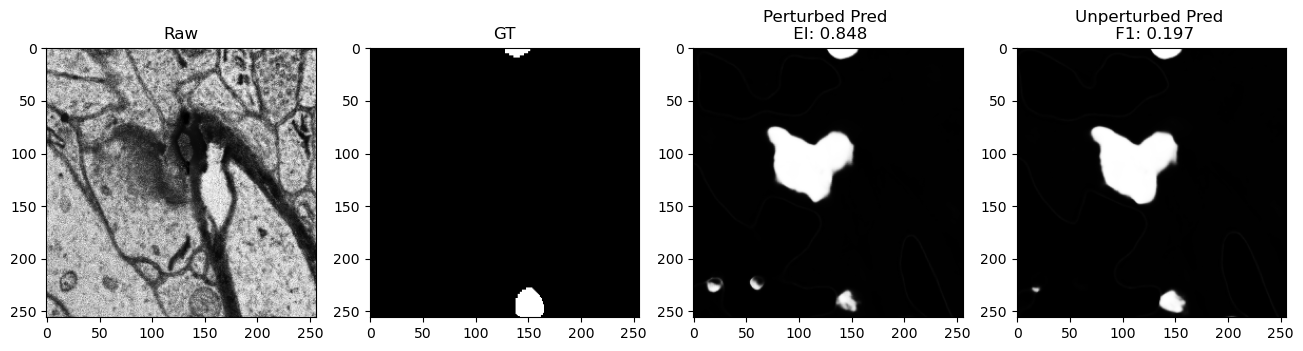

In [49]:
offset = 20
num_samples = 10
for i in low_f1_high_consis_ids[offset:offset+num_samples]:
    _, axs = plt.subplots(1, 4, figsize=(16, 4))
    raw = load_h5(H_gt_path, raw_key, roi=patch_indxs[i])
    gt = load_h5(H_gt_path, gt_key, roi=patch_indxs[i])
    axs[0].imshow(raw.squeeze(), cmap="gray")
    axs[0].set_title("Raw")
    axs[1].imshow(gt.squeeze(), cmap="gray")
    axs[1].set_title("GT")
    p_pred = load_h5(p_path, "predictions", select_index=[i])
    axs[2].imshow(p_pred.squeeze(), cmap="gray")
    axs[2].set_title(f"Perturbed Pred \n EI: {EI_consis[i]:.3f}")
    unp_pred = load_h5(unp_path, "predictions", select_index=[i])
    axs[3].imshow(unp_pred.squeeze(), cmap="gray")
    axs[3].set_title(f"Unperturbed Pred \n F1: {F1_scores[i, 1]:.3f}")
    plt.show()